# Querying the Knowledge Graph

In [9]:
from atomrdf import KnowledgeGraph
from tools4rdf.network.network import OntologyNetwork
from rdflib import Graph
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from pychromatic import Multiplot
from pychromatic.colors import accent
import matplotlib.pyplot as plt

## Setup

In [10]:
# Knowledge graph (atomRDF archive)
kg = KnowledgeGraph.unarchive('wf_archive', compress=False)
print(f'{kg.n_samples} samples')

542 samples


In [18]:
cmso = OntologyNetwork('https://purls.helmholtz-metadaten.de/cmso/')
asmo  = OntologyNetwork('https://purls.helmholtz-metadaten.de/asmo/')
onto  = cmso + asmo
kg.ontology = onto

## Hall-Petch effect

In [19]:
df_hp = kg.query(onto.terms.cmso.AtomicScaleSample, [[onto.terms.asmo.FlowStress, onto.terms.asmo.hasValue], 
                                                     onto.terms.cmso.hasGrainSize])

In [20]:
df_hp.columns = ['AtomicScaleSample', 'value', 'GrainSize']
print(f'{len(df_hp)} rows')
df_hp.head()

221 rows


,AtomicScaleSample,value,GrainSize
0,sample:013e166d-f9d5-4e0f-9808-f6ed64301ffa,4.243982674674016,130.0
1,sample:0157fe08-38d1-4f79-bd39-9c094ed96bcd,3.955849178662869,110.0
2,sample:02e34477-3184-499d-93ce-dee4d32a8298,4.021279426769367,200.0
3,sample:04065e9e-68d0-4b6e-bc06-86b5405d9b8a,4.08418296427737,100.0
4,sample:0419de8d-65d7-4875-926f-a0c12be1a981,3.9067167471299364,110.0


In [21]:
gs = df_hp.GrainSize.astype(float).astype(int)
fs = df_hp.value.astype(float)

unique_gs = np.unique(gs)
n_per_gs  = np.array([fs[gs == g].count() for g in unique_gs])
avg_fs    = np.array([fs[gs == g].mean()  for g in unique_gs])
std_fs    = np.array([fs[gs == g].std()   for g in unique_gs])
sem_fs    = std_fs / np.sqrt(n_per_gs)

k       = 3.2469 +/- 0.4776 GPa nm^(1/2)
sigma_0 = 3.0325 +/- 0.1276 GPa
R^2     = 0.7721


Text(0, 0.5, 'Flow stress (GPa)')

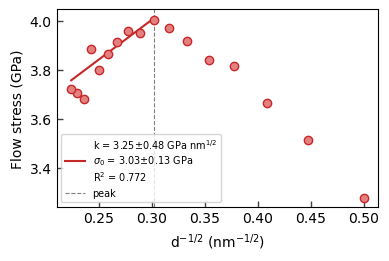

In [22]:
x_hp = (unique_gs / 10) ** -0.5
peak_idx = np.argmax(avg_fs)
mask = np.arange(len(avg_fs)) >= peak_idx

def hp_model(x, k, sigma0):
    return k * x + sigma0

popt, pcov = curve_fit(hp_model, x_hp[mask], avg_fs[mask],
                       sigma=sem_fs[mask], absolute_sigma=True)
k, sigma0 = popt
k_err, sigma0_err = np.sqrt(np.diag(pcov))

y_pred = hp_model(x_hp[mask], *popt)
r_sq = 1 - np.sum((avg_fs[mask] - y_pred)**2) / np.sum((avg_fs[mask] - avg_fs[mask].mean())**2)

print(f'k       = {k:.4f} +/- {k_err:.4f} GPa nm^(1/2)')
print(f'sigma_0 = {sigma0:.4f} +/- {sigma0_err:.4f} GPa')
print(f'R^2     = {r_sq:.4f}')

x_fit = np.linspace(x_hp[mask].min(), x_hp[mask].max(), 100)
y_fit = hp_model(x_fit, *popt)

mlt = Multiplot(width=300)
mlt[0,0].plot(x_hp, avg_fs, 'o',
              color=accent['pred'], markeredgecolor=accent['dred'], zorder=5)
mlt[0,0].plot(x_fit, y_fit, '-', color=accent['dred'],
              label=f'k = {k:.2f}$\\pm${k_err:.2f} GPa nm$^{{1/2}}$\n'
                    f'$\\sigma_0$ = {sigma0:.2f}$\\pm${sigma0_err:.2f} GPa\n'
                    f'R$^2$ = {r_sq:.3f}')
mlt[0,0].axvline(x_hp[peak_idx], ls='--', color='gray', lw=0.8, label='peak')
mlt[0,0].legend(fontsize=7)
mlt[0,0].set_xlabel(r'd$^{-1/2}$ (nm$^{-1/2}$)')
mlt[0,0].set_ylabel(r'Flow stress (GPa)')

## Bulk modulus

In [28]:
SPARQL_BM = '''
PREFIX cmso: <http://purls.helmholtz-metadaten.de/cmso/>
PREFIX rdf:  <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX asmo: <https://purls.helmholtz-metadaten.de/asmo/>
SELECT DISTINCT ?AtomicScaleSample ?BulkModulusValue ?Reference
WHERE {
    ?AtomicScaleSample asmo:hasCalculatedProperty ?BulkModulus .
    ?BulkModulus asmo:hasValue ?BulkModulusValue .
    ?BulkModulus asmo:wasCalculatedBy ?Simulation .
    ?Simulation asmo:hasInteratomicPotential ?Potential .
    ?Potential cmso:hasReference ?Reference .
   { ?AtomicScaleSample rdf:type cmso:AtomicScaleSample . }
   { ?BulkModulus rdf:type asmo:BulkModulus . }
}
'''

results = kg.graph.query(SPARQL_BM)
df_bm_ref = pd.DataFrame(results, columns=[str(v) for v in results.vars])
df_bm_ref['BulkModulusValue'] = df_bm_ref['BulkModulusValue'].astype(float)
df_bm_ref = df_bm_ref.loc[df_bm_ref['BulkModulusValue'] > 100]
df_bm_ref

,AtomicScaleSample,BulkModulusValue,Reference
3,sample:ef26fe02-b559-4321-81c9-683960b6dc71,176.180268,https://doi.org/10.1073/pnas.2113059119
5,sample:ef26fe02-b559-4321-81c9-683960b6dc71,131.861354,https://doi.org/10.1103/physrevmaterials.5.063607
6,sample:ef26fe02-b559-4321-81c9-683960b6dc71,177.792737,https://doi.org/10.1016/j.jnucmat.2010.05.017
11,sample:ef26fe02-b559-4321-81c9-683960b6dc71,184.893127,https://doi.org/10.1038/nmat3401
19,sample:ef26fe02-b559-4321-81c9-683960b6dc71,178.264614,https://doi.org/10.1016/j.susc.2006.02.010
27,sample:ef26fe02-b559-4321-81c9-683960b6dc71,160.829969,https://doi.org/10.1038/s41524-025-01574-w
28,sample:ef26fe02-b559-4321-81c9-683960b6dc71,177.870337,https://doi.org/10.1103/PhysRevB.86.144111
33,sample:ef26fe02-b559-4321-81c9-683960b6dc71,170.349954,https://doi.org/10.1016/j.commatsci.2009.06.025
35,sample:ef26fe02-b559-4321-81c9-683960b6dc71,166.886265,https://doi.org/10.1103/physrevb.69.144113
37,sample:ef26fe02-b559-4321-81c9-683960b6dc71,177.792119,https://doi.org/10.1080/14786430310001613264


In [29]:
pots = np.unique(df_bm_ref.Reference)
bulkm = [df_bm_ref.loc[df_bm_ref.Reference == p, 'BulkModulusValue'].values[0] for p in pots]

In [30]:
bulkm

[170.34995377797134,
 177.79273697738566,
 178.26461409511668,
 184.8931270256197,
 160.829969257318,
 176.18026789749,
 177.79211934087698,
 173.49027108725033,
 177.87033669302664,
 166.88626534143967,
 131.86135351893927]

## C11 elastic constant

In [31]:
SPARQL_C11 = '''
PREFIX cmso: <http://purls.helmholtz-metadaten.de/cmso/>
PREFIX rdf:  <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX asmo: <https://purls.helmholtz-metadaten.de/asmo/>
SELECT DISTINCT ?AtomicScaleSample ?Reference ?ElasticModulusValue
WHERE {
    ?AtomicScaleSample asmo:hasCalculatedProperty ?ElasticModulus .
    ?ElasticModulus rdfs:label ?label .
    ?ElasticModulus asmo:hasValue ?ElasticModulusValue .
    ?ElasticModulus asmo:wasCalculatedBy ?Simulation .
    ?Simulation asmo:hasInteratomicPotential ?Potential .
    ?Potential cmso:hasReference ?Reference .
   { ?AtomicScaleSample rdf:type cmso:AtomicScaleSample . }
   { ?BulkModulus rdf:type asmo:BulkModulus . }
   FILTER (?label = 'C11')
}
'''

results = kg.graph.query(SPARQL_C11)
df_c11 = pd.DataFrame(results, columns=[str(v) for v in results.vars])
df_c11['ElasticModulusValue'] = df_c11['ElasticModulusValue'].astype(float)
df_c11

,AtomicScaleSample,Reference,ElasticModulusValue
0,sample:ef26fe02-b559-4321-81c9-683960b6dc71,https://doi.org/10.1073/pnas.2113059119,245.671257
1,sample:ef26fe02-b559-4321-81c9-683960b6dc71,https://doi.org/10.1103/physrevmaterials.5.063607,217.861694
2,sample:ef26fe02-b559-4321-81c9-683960b6dc71,https://doi.org/10.1016/j.jnucmat.2010.05.017,243.364740
3,sample:ef26fe02-b559-4321-81c9-683960b6dc71,https://doi.org/10.1038/nmat3401,269.092897
4,sample:ef26fe02-b559-4321-81c9-683960b6dc71,https://doi.org/10.1016/j.susc.2006.02.010,241.106318
5,sample:ef26fe02-b559-4321-81c9-683960b6dc71,https://doi.org/10.1038/s41524-025-01574-w,234.468317
6,sample:ef26fe02-b559-4321-81c9-683960b6dc71,https://doi.org/10.1103/PhysRevB.86.144111,243.442065
7,sample:ef26fe02-b559-4321-81c9-683960b6dc71,https://doi.org/10.1016/j.commatsci.2009.06.025,239.549921
8,sample:ef26fe02-b559-4321-81c9-683960b6dc71,https://doi.org/10.1103/physrevb.69.144113,229.652529
9,sample:ef26fe02-b559-4321-81c9-683960b6dc71,https://doi.org/10.1080/14786430310001613264,243.359095


In [32]:
c11m = [df_c11.loc[df_c11.Reference == p, 'ElasticModulusValue'].values[0] for p in pots]

## Defect formation energy 

In [33]:
SPARQL_DEF = '''
PREFIX cmso: <http://purls.helmholtz-metadaten.de/cmso/>
PREFIX rdf:  <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX asmo: <https://purls.helmholtz-metadaten.de/asmo/>
PREFIX podo: <http://purls.helmholtz-metadaten.de/cdos/podo/>
PREFIX cdco: <http://purls.helmholtz-metadaten.de/cdos/cdco/>
SELECT DISTINCT ?AtomicScaleSample ?value ?label
        (GROUP_CONCAT(DISTINCT ?symbol; separator=", ") AS ?elements)
WHERE {
    ?AtomicScaleSample asmo:hasCalculatedProperty ?property .
    ?AtomicScaleSample cmso:hasMaterial ?material .
    ?material cdco:hasCrystallographicDefect ?defect .
    ?AtomicScaleSample cmso:hasSpecies ?species .
    ?species cmso:hasElement ?element .
    ?element cmso:hasChemicalSymbol ?symbol .
    ?property rdfs:label ?label .
    ?property asmo:hasValue ?value .
    { ?Defect rdf:type podo:SubstitutionalImpurity . }
    FILTER (?label = 'DefectFormationEnergy')
}
GROUP BY ?AtomicScaleSample ?value ?label
'''

results = kg.graph.query(SPARQL_DEF)
dfa = pd.DataFrame(results, columns=[str(v) for v in results.vars])
dfa['elements'] = dfa['elements'].apply(str)
dfa[['matrix', 'defect']] = dfa['elements'].str.split(', ', expand=True)
dfa = dfa.drop(columns=['elements'])
dfa

,AtomicScaleSample,value,label,matrix,defect
0,sample:0a373666-714c-4132-bdc8-777fb22814ef,0.5469,DefectFormationEnergy,Fe,Cu
1,sample:7c6e4179-0214-48a0-ab65-56515ce83c7e,-1.2799,DefectFormationEnergy,Fe,Si
2,sample:a2eda732-9068-4a2a-b433-9085189a8352,-0.7987,DefectFormationEnergy,Fe,Al
3,sample:b81ce05e-c579-4f1c-857c-f938b75194ad,0.953,DefectFormationEnergy,Fe,Mg


In [34]:
def_energy = dfa['value'].astype(float).values
def_labels = dfa['defect'].values

## Combined property overview

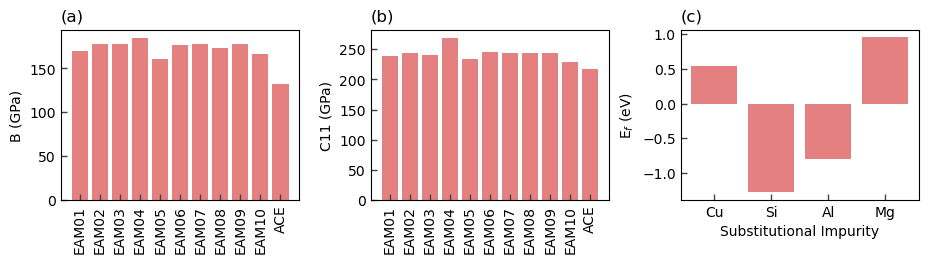

In [35]:
ticklabels = ['EAM01', 'EAM02', 'EAM03', 'EAM04',
              'EAM05', 'EAM06', 'EAM07', 'EAM08',
              'EAM09', 'EAM10', 'ACE']

mlt = Multiplot(width=800, columns=3, ratio=0.2, wspace=.3)
xr = np.arange(len(bulkm))

mlt[0,0].bar(xr, bulkm, color=accent['pred'])
mlt[0,0].set_xticks(xr)
mlt[0,0].set_xticklabels(ticklabels, rotation=90)
mlt[0,0].set_ylabel('B (GPa)')
mlt[0,0].set_title('(a)', loc='left')

mlt[0,1].bar(xr, c11m, color=accent['pred'])
mlt[0,1].set_xticks(xr)
mlt[0,1].set_xticklabels(ticklabels, rotation=90)
mlt[0,1].set_ylabel('C11 (GPa)')
mlt[0,1].set_title('(b)', loc='left')

mlt[0,2].bar(np.arange(len(def_energy)), def_energy, color=accent['pred'])
mlt[0,2].set_xticks(np.arange(len(def_labels)))
mlt[0,2].set_xticklabels(def_labels)
mlt[0,2].set_ylabel(r'E$_f$ (eV)')
mlt[0,2].set_xlabel('Substitutional Impurity')
mlt[0,2].set_title('(c)', loc='left')
plt.savefig('b_c11.png', dpi=300, bbox_inches='tight')